# 1.7.5 Outliers

Diagn?stico exclusivo de DEVELOPMENT. No modifica datasets, no utiliza TEST y no construye la variable objetivo. Se conservan todos los registros. Este notebook corresponde ?nicamente a esta subsecci?n.

In [1]:
"""Diagnóstico descriptivo de extremos. Solo DEVELOPMENT; no modifica los datos."""
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/splits/development_80.csv').is_file())
SOURCE = ROOT / 'data/splits/development_80.csv'
FIGURES = ROOT / 'book/_static/figures'
TABLES = ROOT / 'outputs/tables'
SYMBOLS = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'SOLUSDT']
FIELDS = ['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume',
          'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']


def main():
    fingerprint = hashlib.sha256(SOURCE.read_bytes()).hexdigest()
    df = pd.read_csv(SOURCE)
    df['open_time'] = pd.to_datetime(df['open_time'], utc=True)
    assert len(df) == 214165 and set(df.symbol) == set(SYMBOLS)
    assert df.open_time.between(pd.Timestamp('2020-08-11 06:00', tz='UTC'),
                                pd.Timestamp('2025-07-01 18:00', tz='UTC')).all()
    assert not df.duplicated(['symbol', 'open_time']).any()
    assert np.isfinite(df[FIELDS].to_numpy()).all() and (df.close > 0).all()
    FIGURES.mkdir(parents=True, exist_ok=True)
    TABLES.mkdir(parents=True, exist_ok=True)
    summary, extremes, groups = [], [], {}
    for symbol in SYMBOLS:
        g = df.loc[df.symbol.eq(symbol)].sort_values('open_time').copy()
        consecutive = g.open_time.diff().eq(pd.Timedelta(hours=1))
        g['return_1h_pct'] = (100 * np.log(g.close / g.close.shift())).where(consecutive)
        groups[symbol] = g
        for field in FIELDS + ['return_1h_pct']:
            x = g[field].dropna()
            q1, q3 = x.quantile([.25, .75], interpolation='linear')
            iqr = q3-q1
            lower, upper = q1-1.5*iqr, q3+1.5*iqr
            flag = (g[field] < lower) | (g[field] > upper)
            summary.append(dict(symbol=symbol, variable=field, n=len(x), q1=q1, q3=q3,
                                iqr=iqr, lower=lower, upper=upper, flagged=int(flag.sum()),
                                percent=100*flag.sum()/len(x)))
            if field in ['return_1h_pct', 'quote_asset_volume']:
                g[field+'_flag'] = flag
                idx = g[field].abs().idxmax() if field == 'return_1h_pct' else g[field].idxmax()
                extremes.append(dict(symbol=symbol, variable=field,
                                     open_time=g.loc[idx, 'open_time'].isoformat(),
                                     value=float(g.loc[idx, field])))
    result = pd.DataFrame(summary)
    result.to_csv(TABLES / 'development_outliers_iqr.csv', index=False)
    pd.DataFrame(extremes).to_csv(TABLES / 'development_outliers_extremes.csv', index=False)
    # Gráficos por activo: no se mezclan escalas de activos diferentes.
    plt.rcParams.update({'font.size': 10})
    for kind in ['boxplots', 'distributions', 'timeline']:
        fig, axes = plt.subplots(5, 2, figsize=(13, 15), constrained_layout=True)
        for i, symbol in enumerate(SYMBOLS):
            g = groups[symbol]
            for j, field in enumerate(['return_1h_pct', 'quote_asset_volume']):
                ax = axes[i, j]
                x = g[field].dropna()
                stats = result.loc[result.symbol.eq(symbol) & result.variable.eq(field)].iloc[0]
                label = 'Retorno horario (%)' if j == 0 else 'Volumen (USDT)'
                ax.set_title(f'{symbol} — {label}')
                if kind == 'boxplots':
                    ax.boxplot(x, vert=False, whis=1.5, flierprops=dict(marker='.', markersize=2, alpha=.25))
                    ax.set_yticks([])
                    # Cambio de escala únicamente visual; IQR calculado en unidades originales.
                    ax.set_xscale('symlog', linthresh=1 if j == 0 else 1e6)
                    ax.set_xlabel(label + ' · escala symlog')
                elif kind == 'distributions':
                    ax.hist(x, bins=80, color='#2563a6', log=True)
                    ax.axvline(stats.lower, color='#c2410c', linestyle='--')
                    ax.axvline(stats.upper, color='#c2410c', linestyle='--')
                    ax.set_xlabel(label)
                    ax.set_ylabel('Frecuencia (escala log)')
                else:
                    ax.plot(g.open_time, g[field], color='#2563a6', linewidth=.35, alpha=.6)
                    flagged = g.loc[g[field+'_flag']]
                    ax.scatter(flagged.open_time, flagged[field], color='#c2410c', s=2, rasterized=True)
                    ax.set_ylabel(label)
                    if j == 1:
                        ax.set_yscale('symlog', linthresh=1e6)
                        ax.set_ylabel(label + ' · symlog')
                    ax.tick_params(axis='x', rotation=25)
                ax.grid(alpha=.2)
        titles = {'boxplots':'Boxplots por activo · DEVELOPMENT · bigotes de 1.5 IQR',
                  'distributions':'Distribuciones · DEVELOPMENT · líneas naranjas: límites IQR',
                  'timeline':'Contexto temporal · DEVELOPMENT · naranja: valores señalados por IQR'}
        fig.suptitle(titles[kind], fontsize=15)
        fig.savefig(FIGURES / f'development_outliers_{kind}.png', dpi=160)
        plt.close(fig)
    assert fingerprint == hashlib.sha256(SOURCE.read_bytes()).hexdigest()
    (TABLES / 'development_outliers_metadata.json').write_text(json.dumps({
        'source': 'data/splits/development_80.csv', 'sha256': fingerprint,
        'rule': 'Por activo y variable: x < Q1 - 1.5 IQR o x > Q3 + 1.5 IQR',
        'quantiles': 'Interpolación lineal', 'rows': len(df),
        'treatment': 'Conservar todos los registros; sin imputación, recorte ni winsorización',
        'versions': {'pandas': pd.__version__, 'numpy': np.__version__, 'matplotlib': matplotlib.__version__}
    }, indent=2, ensure_ascii=False), encoding='utf-8')
    print(result.loc[result.variable.isin(['return_1h_pct', 'quote_asset_volume']),
                     ['symbol','variable','n','lower','upper','flagged','percent']].to_string(index=False))
    print('\nExtremos observados (timestamp de apertura UTC):')
    print(pd.DataFrame(extremes).to_string(index=False))
    return result


if __name__ == '__main__':
    main()


 symbol           variable     n         lower        upper  flagged   percent
BTCUSDT quote_asset_volume 42833 -1.064742e+08 2.823192e+08     2818  6.579040
BTCUSDT      return_1h_pct 42822 -9.864181e-01 1.005029e+00     3866  9.028070
ETHUSDT quote_asset_volume 42833 -5.019531e+07 1.345052e+08     2844  6.639740
ETHUSDT      return_1h_pct 42822 -1.298717e+00 1.324525e+00     3838  8.962683
BNBUSDT quote_asset_volume 42833 -1.410961e+07 3.198237e+07     4356 10.169729
BNBUSDT      return_1h_pct 42822 -1.245634e+00 1.272617e+00     3901  9.109803
XRPUSDT quote_asset_volume 42833 -1.308416e+07 3.265367e+07     4469 10.433544
XRPUSDT      return_1h_pct 42822 -1.562369e+00 1.572546e+00     3836  8.958012
SOLUSDT quote_asset_volume 42833 -2.229408e+07 4.335830e+07     3116  7.274765
SOLUSDT      return_1h_pct 42822 -2.271181e+00 2.273043e+00     3244  7.575545

Extremos observados (timestamp de apertura UTC):
 symbol           variable                 open_time         value
BTCUSDT quote_

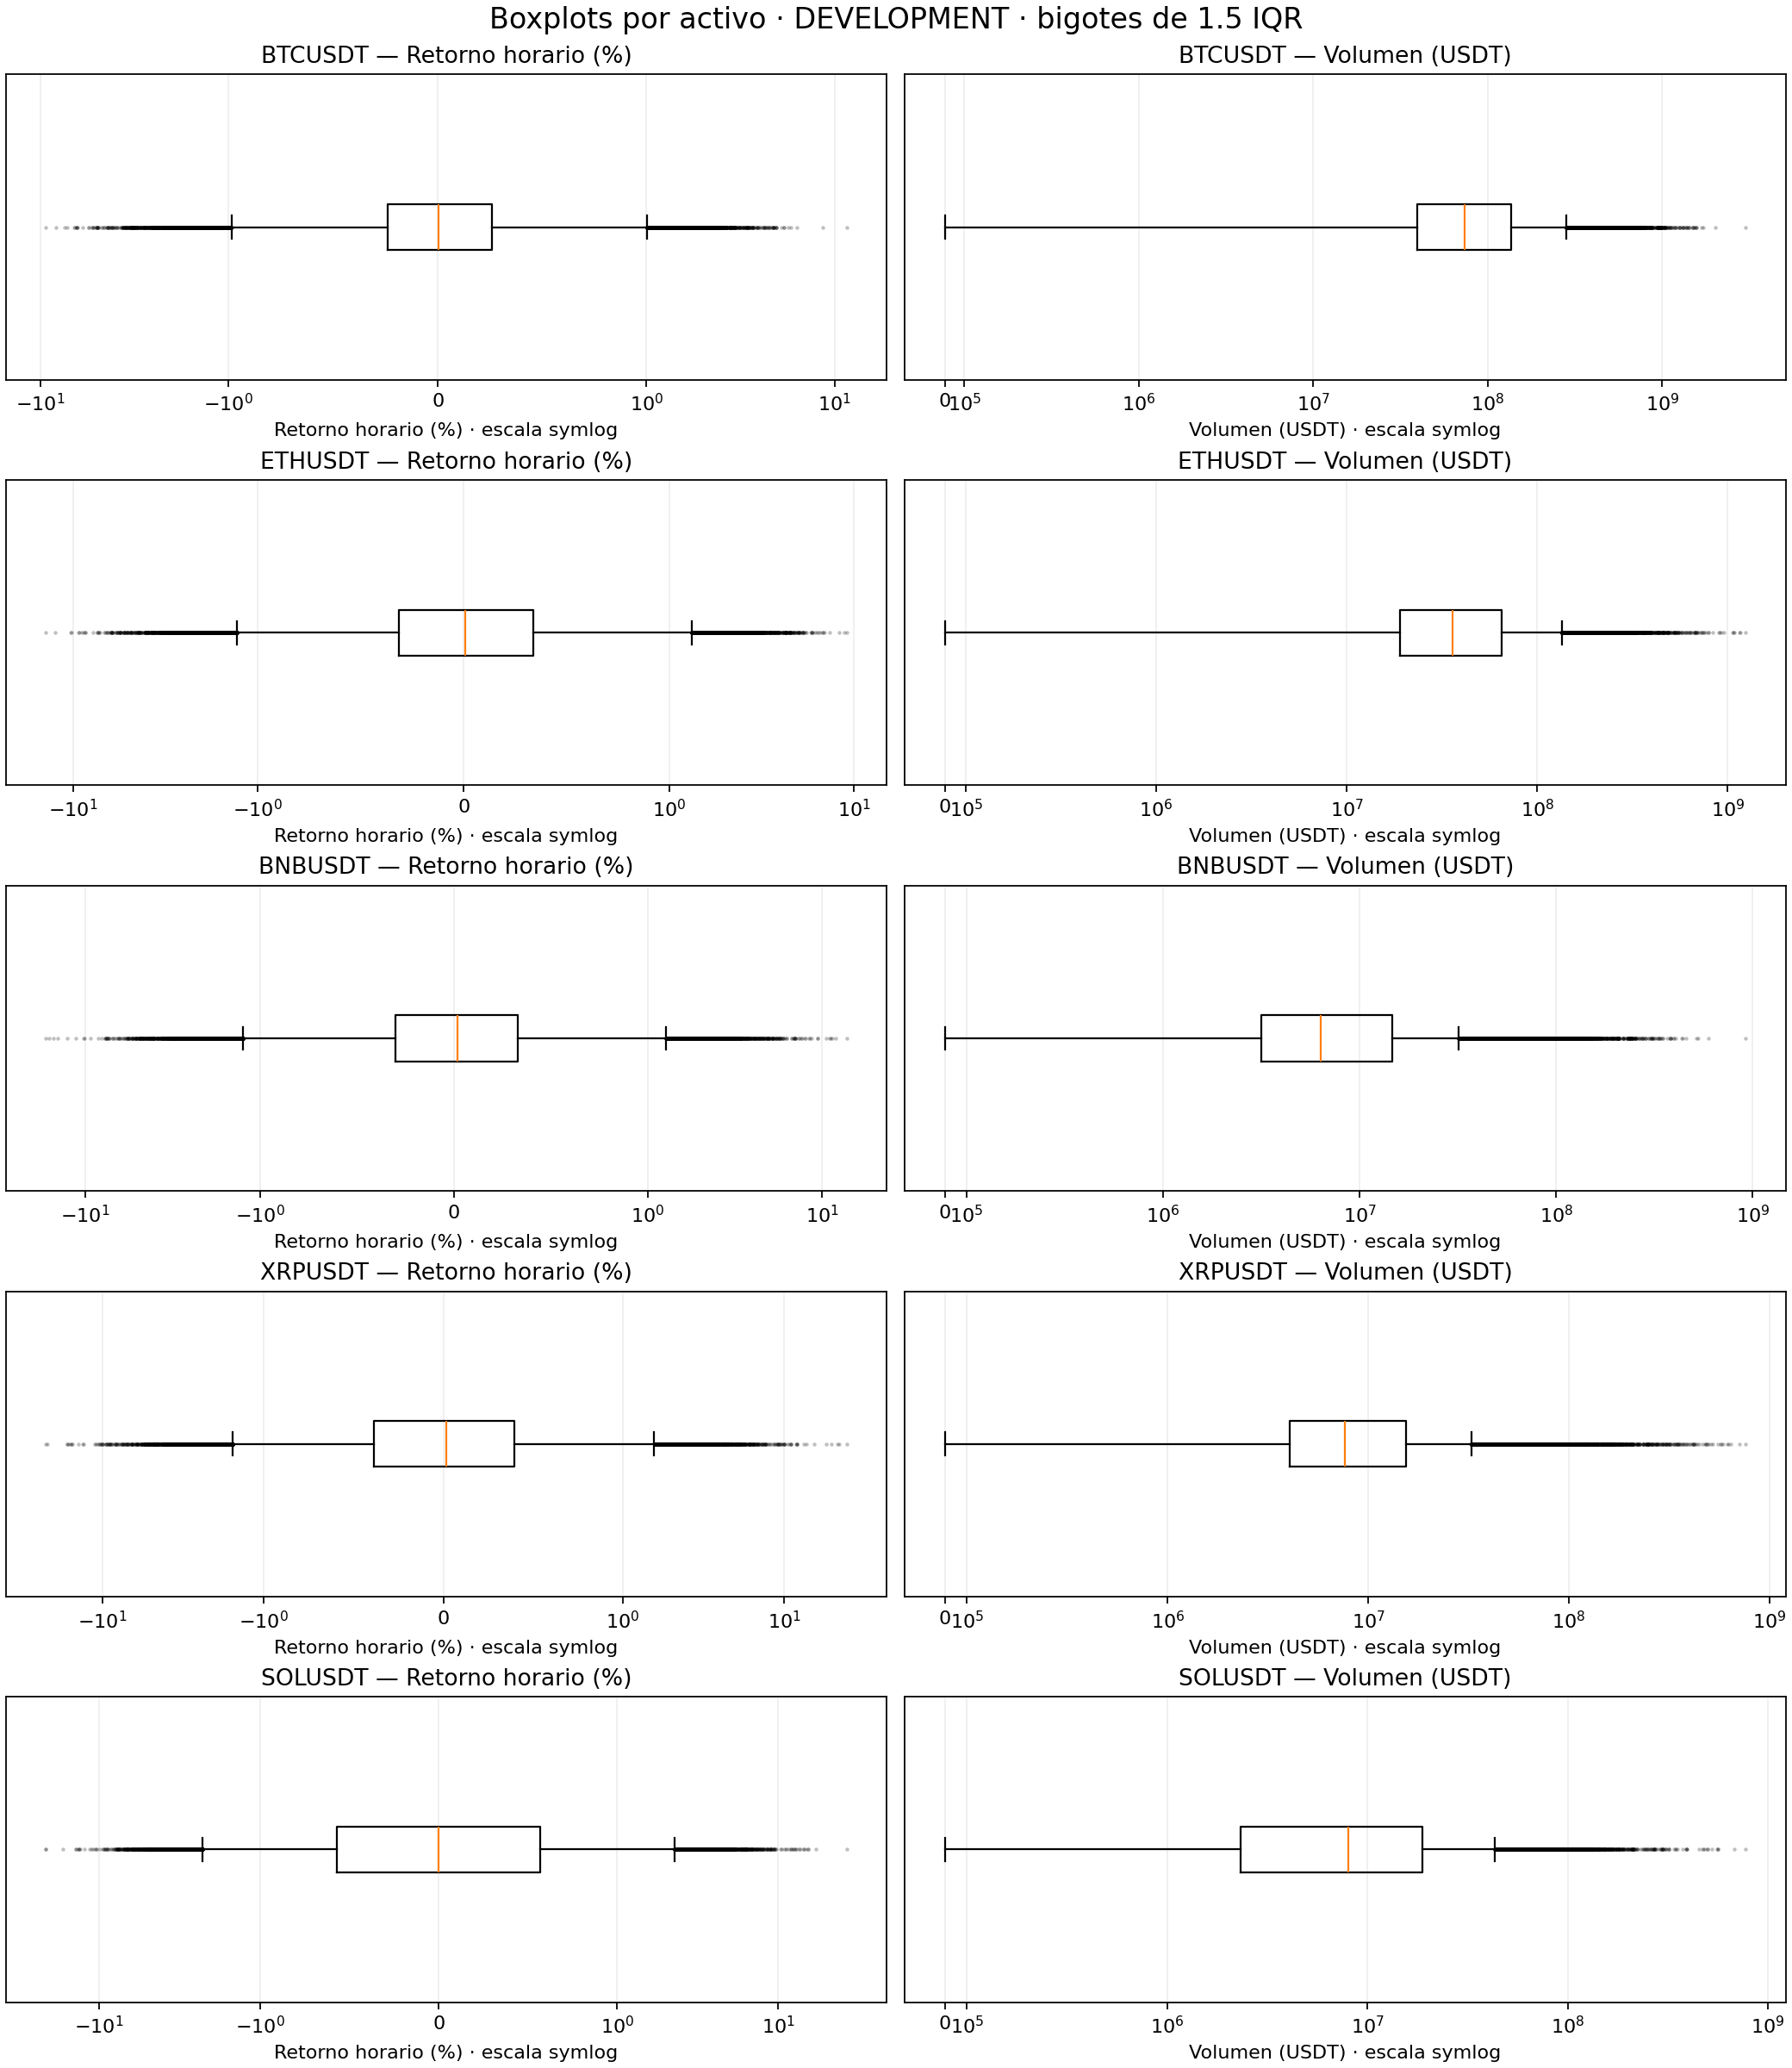

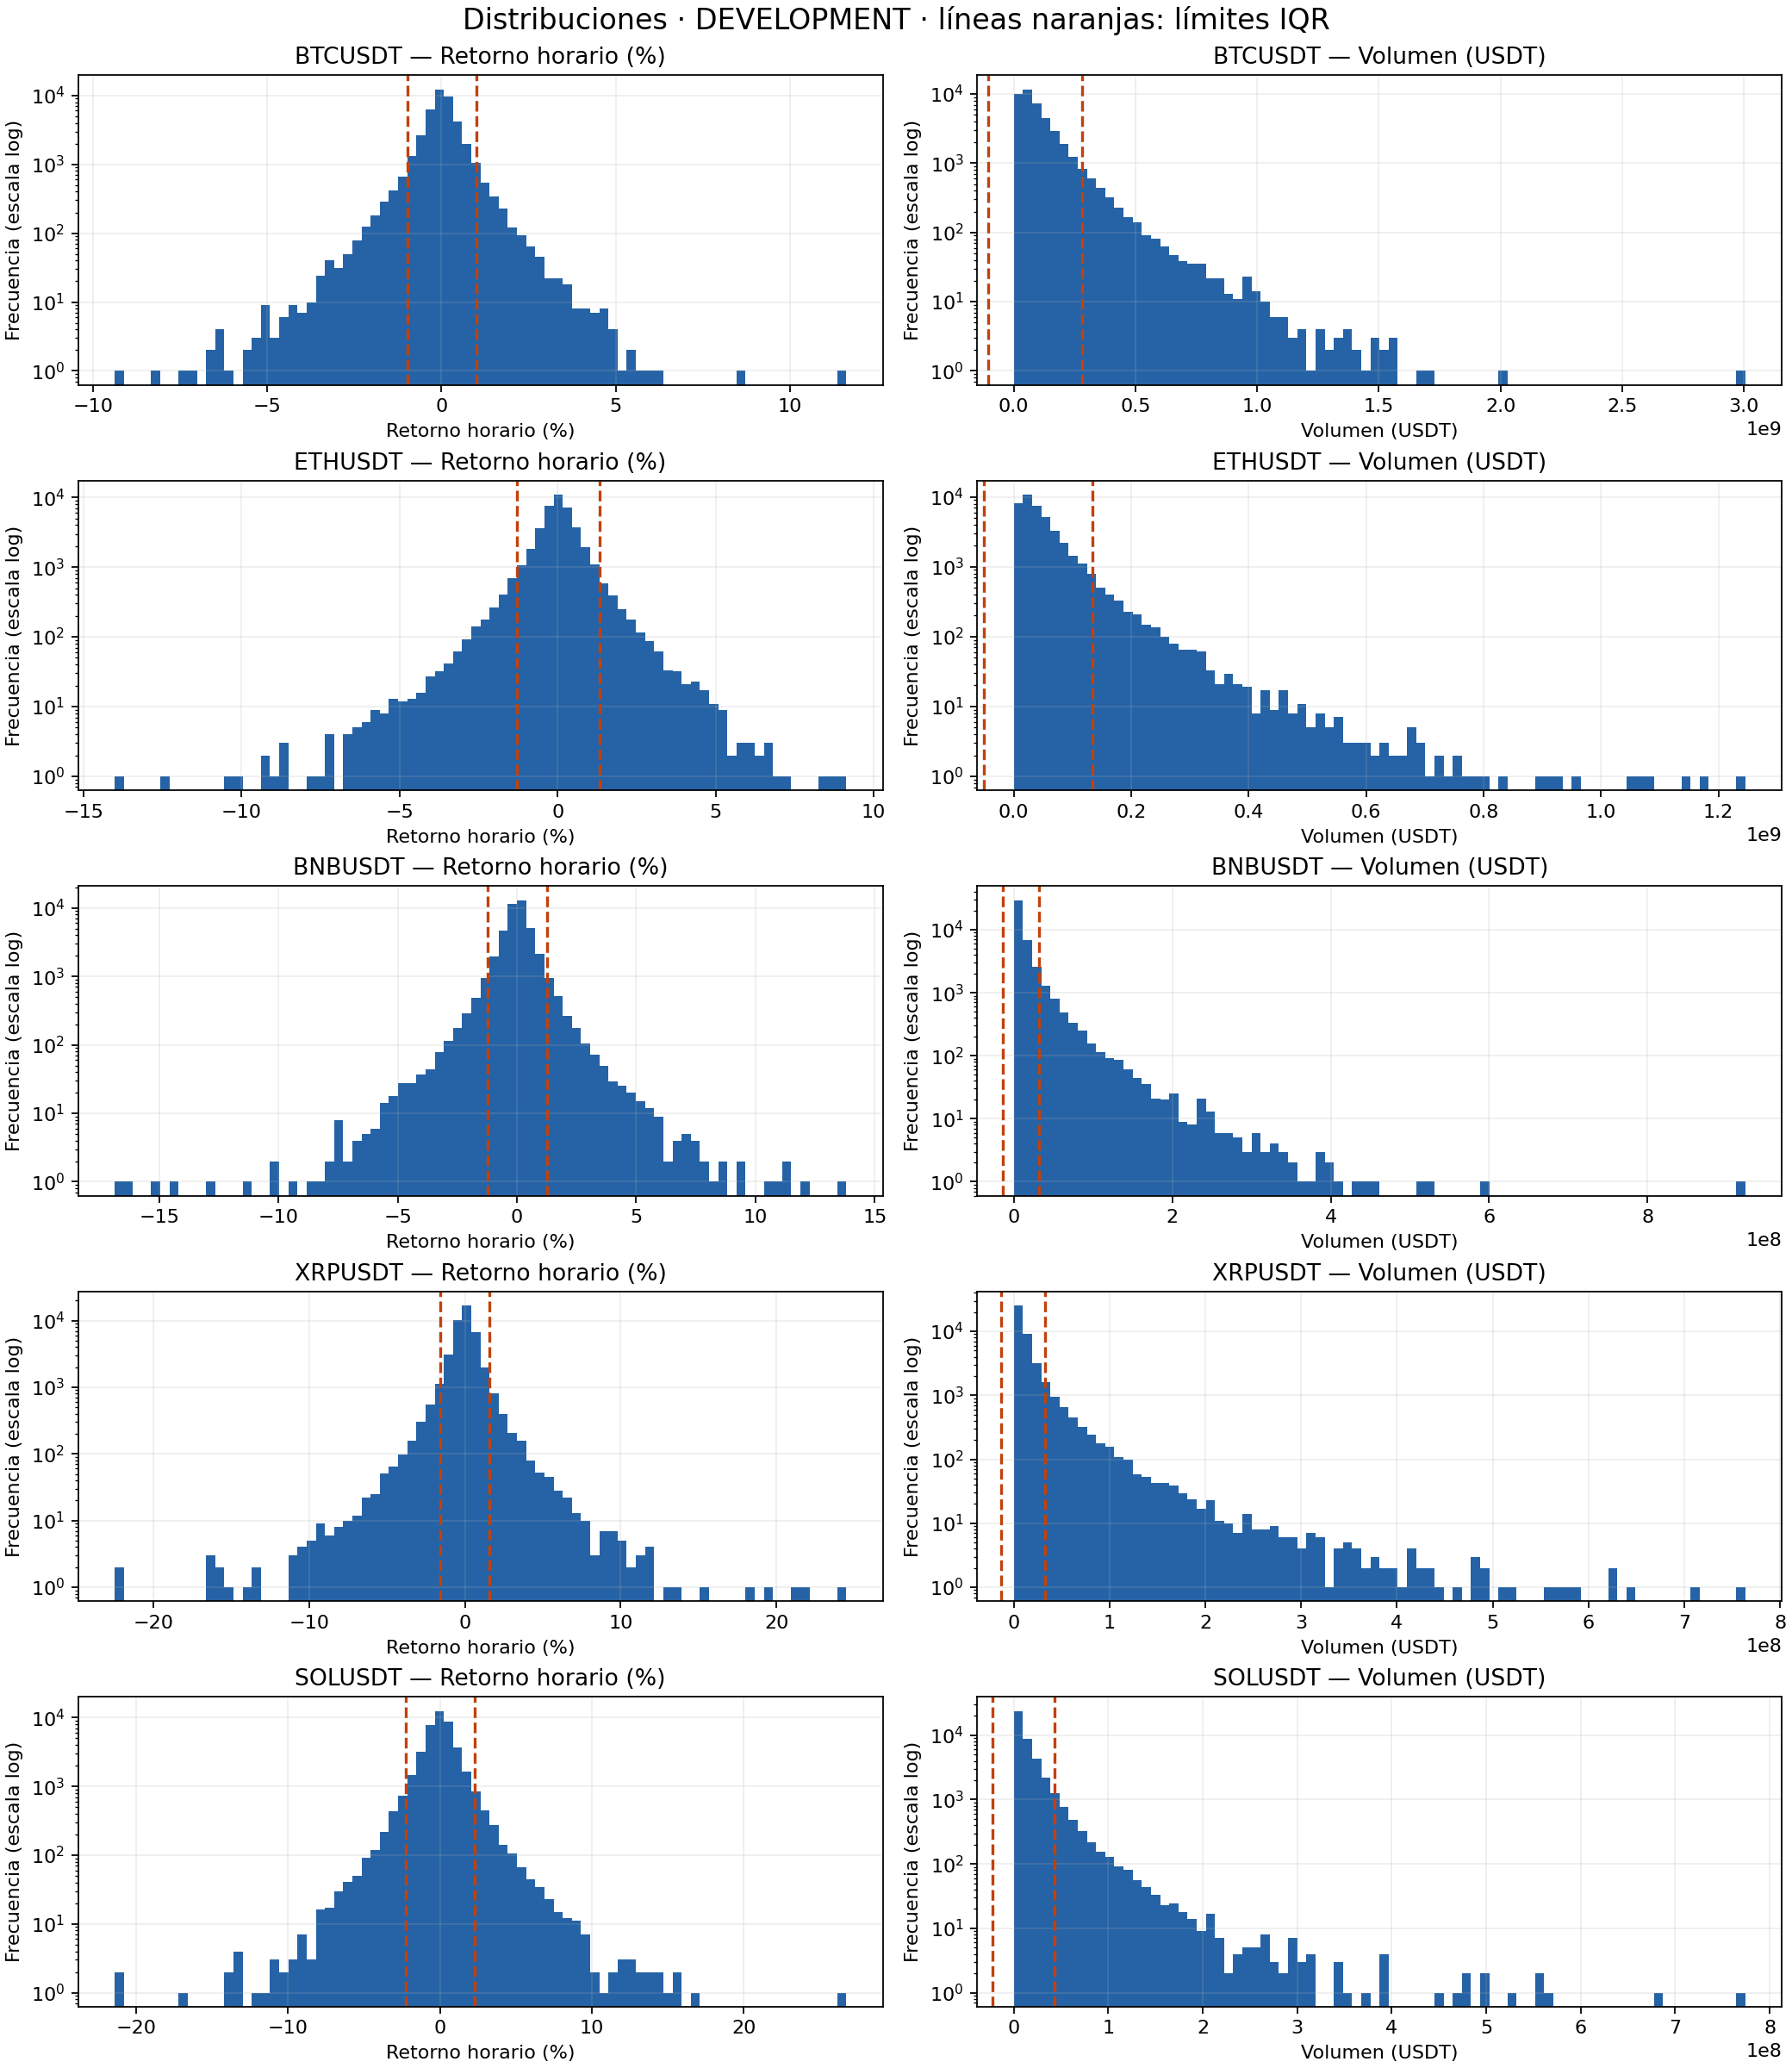

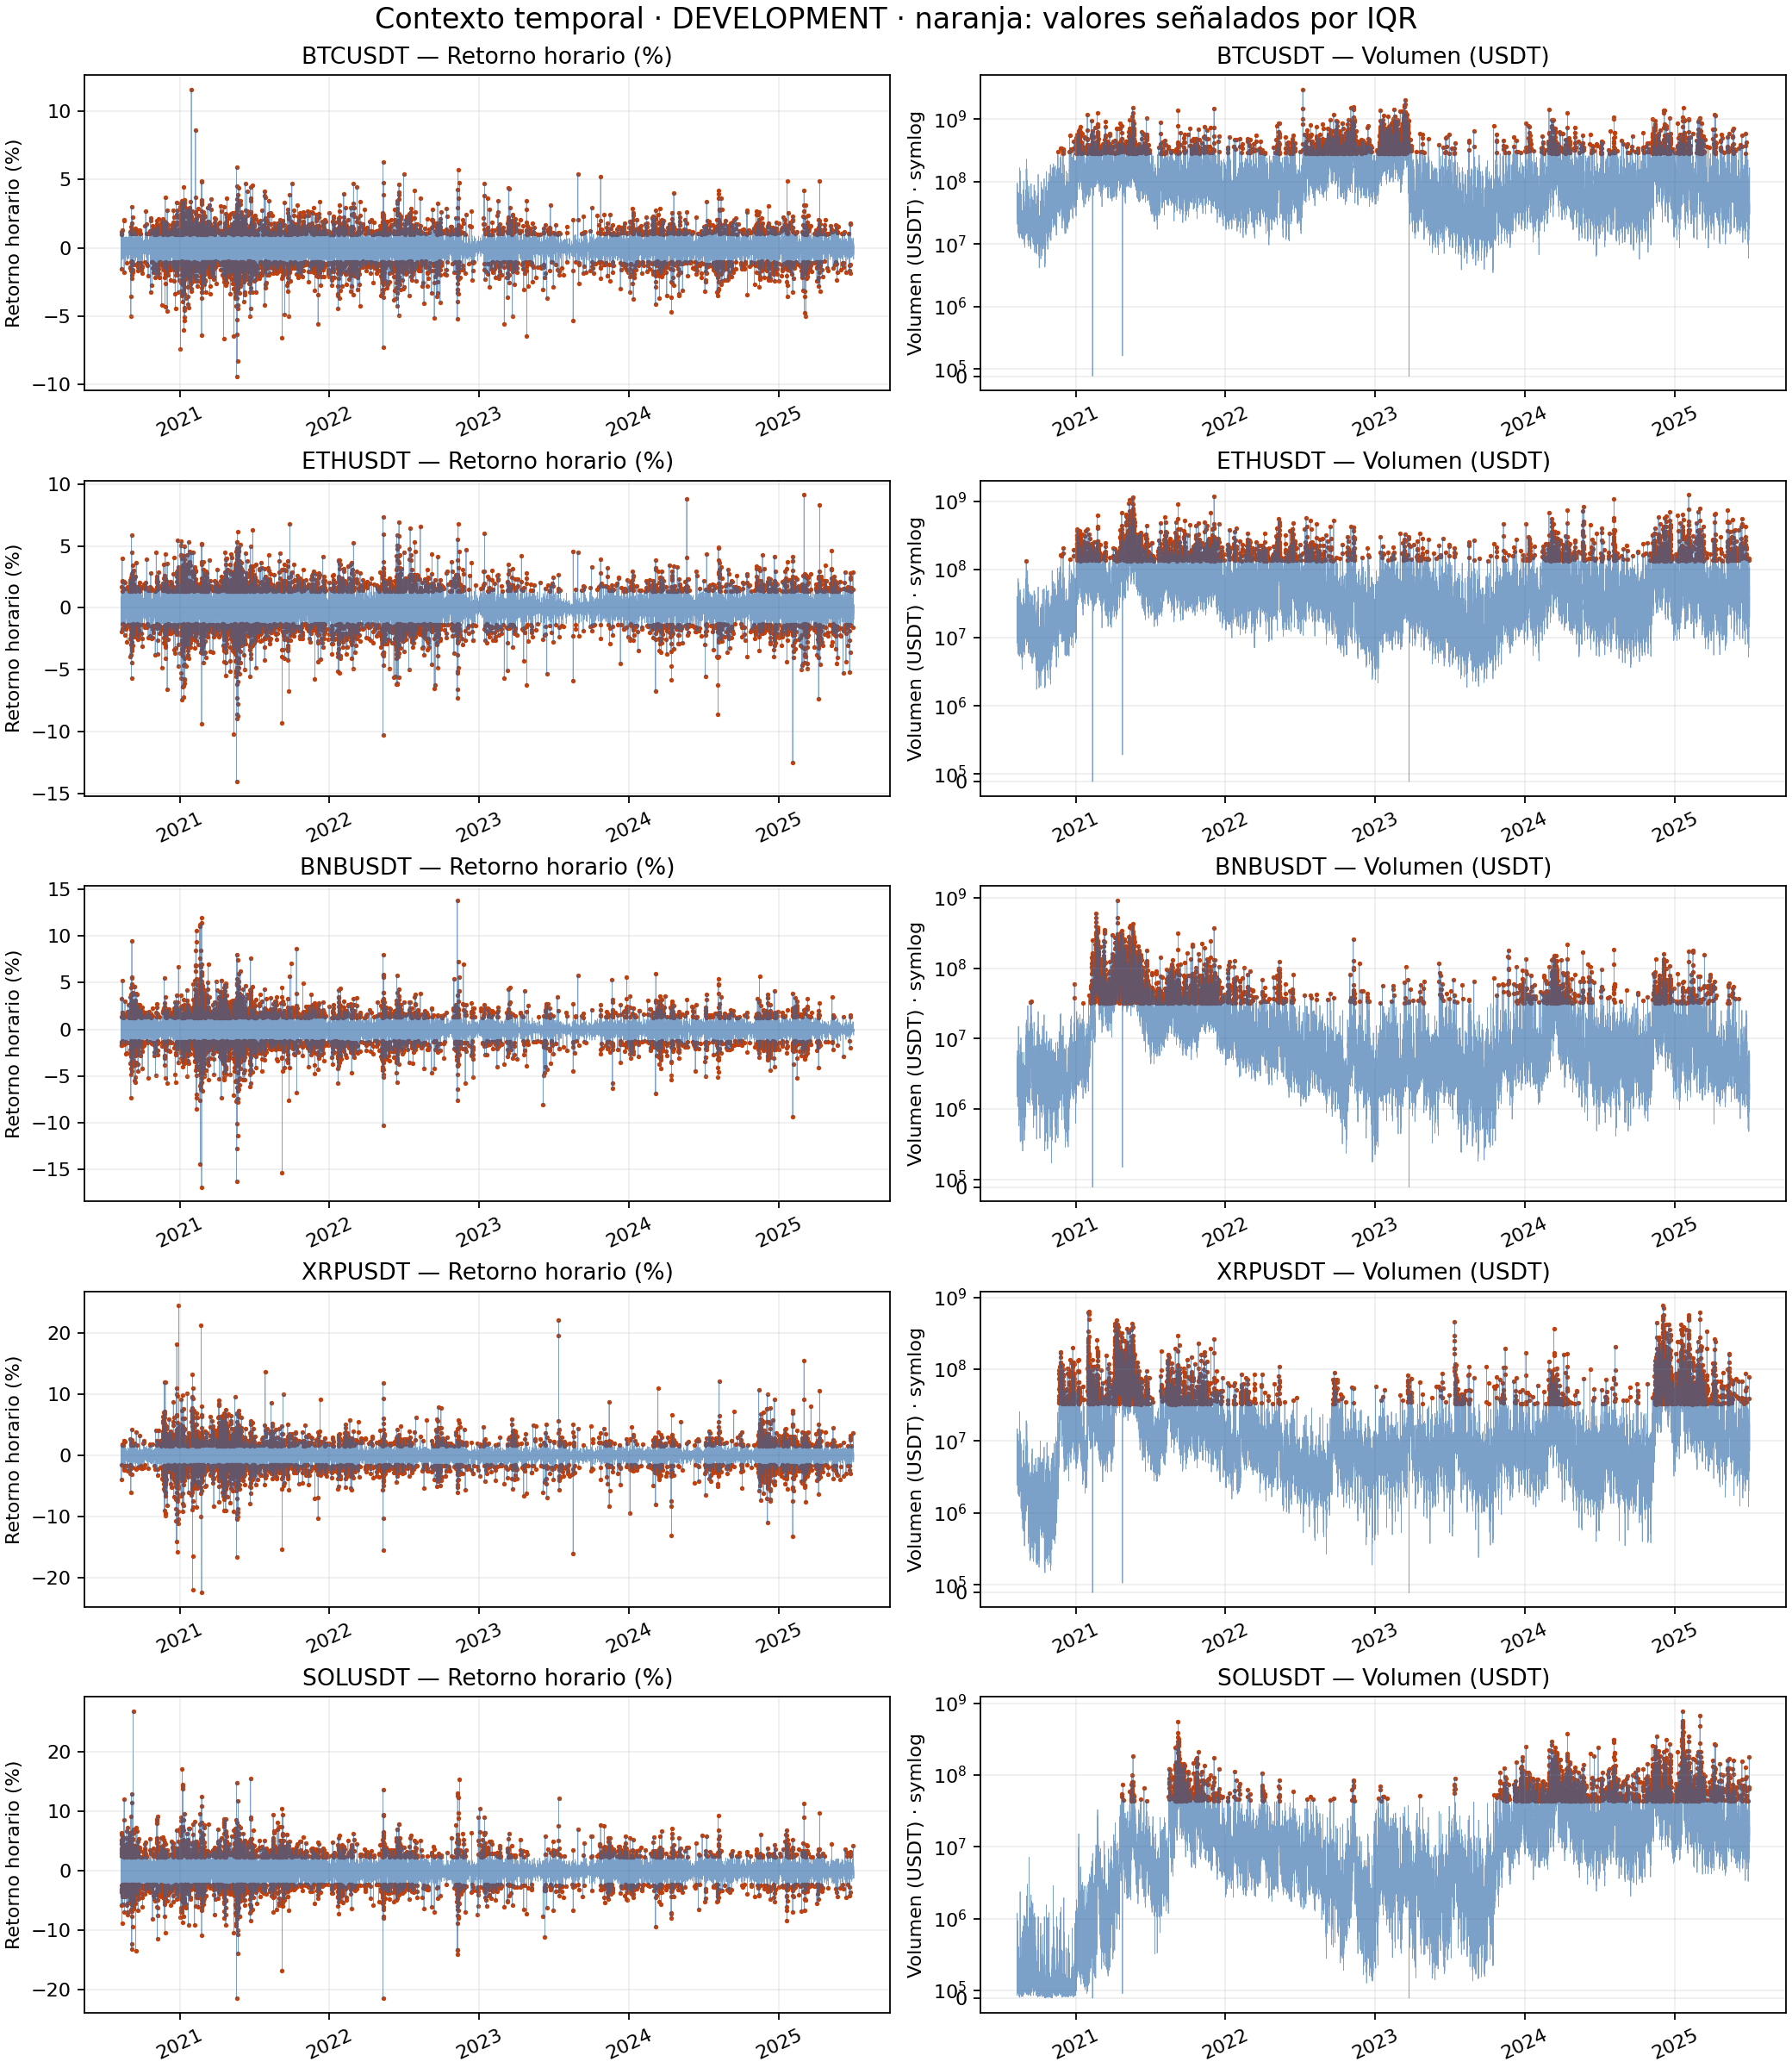

In [2]:
from IPython.display import display, Image
for kind in ['boxplots', 'distributions', 'timeline']:
    display(Image(filename=str(FIGURES / f'development_outliers_{kind}.png')))

Los candidatos IQR no se interpretan autom?ticamente como errores. No se eliminan ni winsorizan observaciones. Los umbrales son descriptivos de DEVELOPMENT; cualquier transformaci?n futura deber? ajustarse dentro de cada partici?n de entrenamiento.

Referencia del criterio: [NIST ? Box Plot](https://itl.nist.gov/div898/handbook/eda/section3/boxplot.htm).